# Cleaned email dataset will be loading and preprocessing using Regula Expressions and NLP. The dataset will be trainning with 4 ML algorithms such as LG,NB,RF, and SVM

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
email_data = pd.read_csv(r"C:\Users\vasil\OneDrive\ScamLens Dissertation\ScamLens Project\data\cleaned\email_cleaned.csv")

In [3]:
email_data.head(50)

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...
5,0,larry king live at escapenumber escapenumber p...
6,0,michael pobega wrote i'm not sure if it's the ...
7,0,hi i have this error tr sample escapenumber es...
8,1,works gateway world art explore tattooing full...
9,1,upon this account he is not only very cautious...


In [4]:
email_data.info

<bound method DataFrame.info of        label                                               text
0          1  ounce feather bowl hummingbird opec moment ala...
1          1  wulvob get your medircations online qnb ikud v...
2          0   computer connection from cnn com wednesday es...
3          1  university degree obtain a prosperous future m...
4          0  thanks for all your answers guys i know i shou...
...      ...                                                ...
83443      0  hi given a date how do i get the last date of ...
83444      1  now you can order software on cd or download i...
83445      1  dear valued member canadianpharmacy provides a...
83446      0  subscribe change profile contact us long term ...
83447      1  get the most out of life ! viagra has helped m...

[83448 rows x 2 columns]>

In [5]:
email_data.columns


Index(['label', 'text'], dtype='object')

In [6]:
email_data['label'].value_counts()


label
1    43910
0    39538
Name: count, dtype: int64

In [7]:
email_data.groupby('label').first()
email_data[email_data['label']==0].head()

,label,text
2,0,computer connection from cnn com wednesday es...
4,0,thanks for all your answers guys i know i shou...
5,0,larry king live at escapenumber escapenumber p...
6,0,michael pobega wrote i'm not sure if it's the ...
7,0,hi i have this error tr sample escapenumber es...


#### The cleaned email_data file contains 83448 rows and 2 columns 'label'-represent '0 - for Ham emails text', and '1 - for Spam emails text'

#### The dataset email_data was preprocessing using NL stopword remover to remove noices, and lemmatizer to convert hte word in base form. Regular Expressions was used to replace numbers, URL, and email address, convert the text into lowercase, remove special characters, and remove spaces. Those functions were used in the sms_data dataset preprocessing.

In [8]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [9]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [10]:
# This function convert everything in lower case.
def convert_lowercase(text):
    text = text.lower()
    return text

In [11]:
# This function replace and keep the nuber with 'NUMBER' instead to removed.
def replace_numbers(text):
    text = re.sub(r'\d+', 'NUMBER',text)
    return text

In [12]:
# This function remove special characters, will remove everything which is not a letter 'a-z, A-Z, and spaces.
def remove_special_characters(text):
    text = re.sub(r'[^a-zA-Z\s]','',text)
    return text


In [13]:
#This function remove the unnecessary spaces in the text.
def remove_extra_spaces(text):
    text = re.sub(r'\s+', ' ', text)
    return text

In [14]:
# This function replace the link URL with 'URL' without remove it.
def replace_links(text):
    text = re.sub(r'https\S+|www\S+', 'URL', text)
    return text

In [15]:
# This function replace the email with the word 'EMAIL' instead removing it.
def replace_emails(text):
    text = re.sub(r'\S+@\S+', 'EMAIL',text)
    return text

In [16]:
"""This function split the sentence into individual words,
check if the word belong to the stop-word list, 
using for na dif conditions, At the end the function return jioned words in one sentence."""
def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

In [17]:
"""This function create a object and convert the word in base form using for in condition, 
add together in one sentence."""
def lemmatize_text(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words]
    return ' '.join(words)

In [18]:
# Creating one main function and adding all separated functions for preprocessing text in one place.
def clean_email_text(text):
    text = convert_lowercase(text)
    text = replace_numbers(text)
    text = remove_special_characters(text)
    text = remove_extra_spaces(text)
    text = replace_links(text)
    text = replace_emails(text)
    text = lemmatize_text(text)
    text = remove_stopwords(text)
    return text

#### Creating a new column containing the clean text applied from the main function clean_email_text.

In [19]:

email_data['cleaned_text'] = email_data['text'].apply(clean_email_text)

In [20]:
email_data[['text','cleaned_text']].head()

,text,cleaned_text
0,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...
1,wulvob get your medircations online qnb ikud v...,wulvob get medircations online qnb ikud viagra...
2,computer connection from cnn com wednesday es...,computer connection cnn com wednesday escapenu...
3,university degree obtain a prosperous future m...,university degree obtain prosperous future mon...
4,thanks for all your answers guys i know i shou...,thanks answer guy know checked rsync manual wo...


#### Splitting the dataset into 'X' set, and 'y' set. Applying train_test_split with test_size 80/20

In [21]:
X = email_data['cleaned_text']
y = email_data['label']

In [22]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size =0.2,
    random_state = 42,
    stratify = y
)

#### Applying TF-IDF for converting the text into numerical vectors and count how often the word appears in the text and in the entire document.

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

# Applying Naive Bayes Algorithm

In [24]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf,y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)


In [25]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test,y_pred_nb)

print('Naive Bayes Accuracy:',nb_accuracy)

Naive Bayes Accuracy: 0.9737567405632115


#### The Multinomial Naive Bayes algorithm acheived an accuracy of 97.38% on the email dataset. The model produced a spam precision score of 99% and a recall score of 96% indicating strong performance in identifiying spam emails.

In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      7908
           1       0.99      0.96      0.97      8782

    accuracy                           0.97     16690
   macro avg       0.97      0.97      0.97     16690
weighted avg       0.97      0.97      0.97     16690



#### The confusion matrix demontrate that the Naive Bayes algorithm correctly identified 7,794 ham emails and 8,458 spam emails. Only 114 ham emails were incorrectly classified as Spam emails, and 324 Spam emails were incorrectly classified as Ham emails. Overall the algorithm indicated strong classification performance.

In [27]:
from sklearn.metrics import confusion_matrix
email = confusion_matrix(y_test,y_pred_nb)
print(email)

[[7794  114]
 [ 324 8458]]


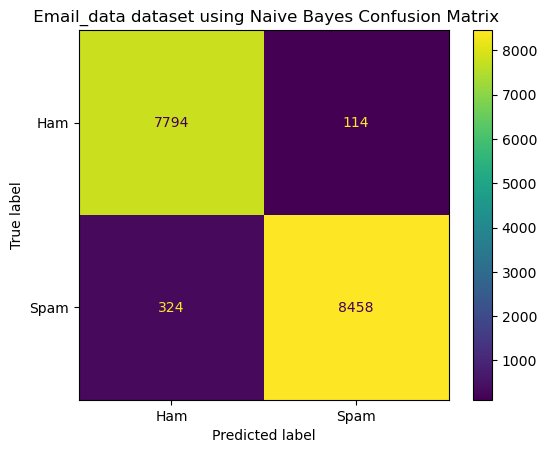

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_nb,
    display_labels = ['Ham','Spam']
)
plt.title(' Email_data dataset using Naive Bayes Confusion Matrix' )
plt.show()

# Applying Logistic Regression Algorithm

In [29]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

#### The Logistic Regression model achieved an accuracy score of 98.37%, with precission of 99% and recall csore of 98%. The algorithm performed with strong achievents of identifying spam emails.

In [30]:
lr_accuracy = accuracy_score(y_test,y_pred_lr)
print('Logistic Regression Accuracy:',lr_accuracy)

print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.9837028160575195
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7908
           1       0.98      0.99      0.98      8782

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



In [31]:
from sklearn.metrics import confusion_matrix
email = confusion_matrix(y_test,y_pred_lr)
print(email)

[[7728  180]
 [  92 8690]]


#### The Logistic Regression showed that 7,728 ham emails and 8,690 spam emails were incorrectly correctly classified. Only 180 ham emails were classified as spam while 92 spam emails were incorrectly classified as ham emails.
#### Compared with the Naive Bayes model, Logistic Regression achieved higher overall performance. The model reduced the number of false negatives from 324 to 92, meaning fewer spam emails were incorrectrly classified as ham imails.

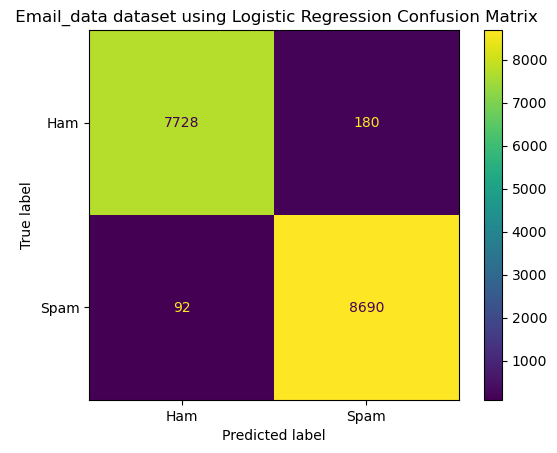

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels = ['Ham','Spam']
)
plt.title(' Email_data dataset using Logistic Regression Confusion Matrix' )
plt.show()

# Applying Support Vector Machine Algorithm

In [33]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf,y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

#### The Support Vector Mshine achieved an accuracy of 99.03, as well as 99% fro precision, recall and F1 score for each class. The model indicated that was highly effective at distinguishing between ham and spam emails.

In [34]:
svm_accuracy = accuracy_score(y_test,y_pred_svm)
print('SVM Accuracy:',svm_accuracy)

print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9902935889754344
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7908
           1       0.99      0.99      0.99      8782

    accuracy                           0.99     16690
   macro avg       0.99      0.99      0.99     16690
weighted avg       0.99      0.99      0.99     16690



In [35]:
from sklearn.metrics import confusion_matrix

svm_cm = confusion_matrix(y_test, y_pred_svm)

print(svm_cm)

[[7799  109]
 [  53 8729]]


#### The SVM corectly identified 8,729 spam emails and 7,799 ham emails. The model incorrectly classified 109 ham emails as spam emails while only 53 spam emails were rwong classified as ham emails. Compared to the Naive Bayes, and Logistic Regression the SVM model produced the lower number of classificaton errors and achieved the highest overall performance.

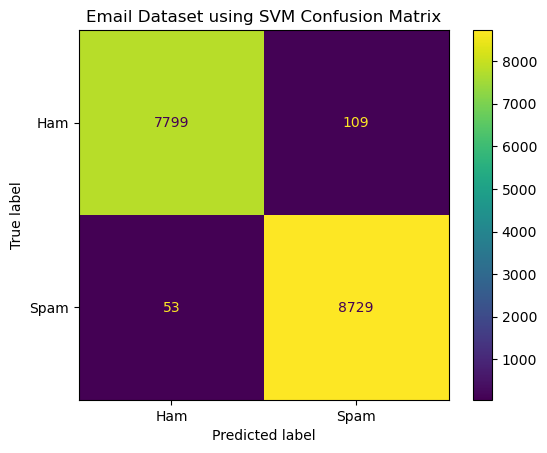

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm,
    display_labels=['Ham', 'Spam']
)

plt.title('Email Dataset using SVM Confusion Matrix')
plt.show()

# Applying Random Forest Algorithm

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

rf_model.fit(X_train_tfidf,y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

In [45]:
rf_accuracy = accuracy_score(y_test,y_pred_rf)
print('Random Forest Accuracy:',rf_accuracy)

print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy: 0.9823247453565009
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7908
           1       0.99      0.98      0.98      8782

    accuracy                           0.98     16690
   macro avg       0.98      0.98      0.98     16690
weighted avg       0.98      0.98      0.98     16690



In [46]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[7797  111]
 [ 184 8598]]


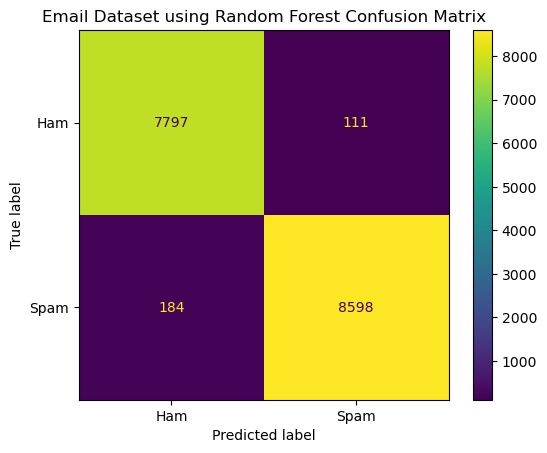

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['Ham', 'Spam']
)

plt.title('Email Dataset using Random Forest Confusion Matrix')
plt.show()

#### Comparison table of tested algorithms and achieved score on Email dataset

In [42]:
results = pd.DataFrame({
    'Model':['Naive Bayes', 'Logistic Regression', 'Support Vector Machine', 'Random Forest'],
    'Accuracy':[0.97,0.98,0.99,0.98],
    'Spam Recall':[0.99, 0.98, 0.99,0.98],
    'Spam F1':[0.97, 0.98, 0.99, 0.98]
    
})

In [43]:
results

,Model,Accuracy,Spam Recall,Spam F1
0,Naive Bayes,0.97,0.99,0.97
1,Logistic Regression,0.98,0.98,0.98
2,Support Vector Machine,0.99,0.99,0.99
3,Random Forest,0.98,0.98,0.98


#### The SVM model was performed and achieved the best results among other algorithms and was saved in the models folder where the model will be used into ScamLens. Moreover, TF-IDF Vectorizer model was saved as well into models folder.

In [48]:
import joblib
joblib.dump(svm_model,'../models/email_svm_model.pkl')

['../models/email_svm_model.pkl']

In [49]:
joblib.dump(tfidf,'../models/email_tfidf.pkl')

['../models/email_tfidf.pkl']